In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset (replace file path with local dataset location)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)

# Column names as per NSL-KDD documentation
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label'
]

train_data.columns = column_names
test_data.columns = column_names

# Binary classification label encoding
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# EDA: Class imbalance visualization
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()

# Check for missing values
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())

# Preprocessing pipelines
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label'])

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Prepare data
X_train = train_data.drop(columns=['label'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label'])
y_test = test_data['label']

X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced')
clf.fit(X_train_preprocessed, y_train)
y_pred = clf.predict(X_test_preprocessed)

# Report metrics
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['attack','normal']))

# Confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC curve and AUC
y_test_bin = (y_test == 'normal').astype(int)
y_score = clf.predict_proba(X_test_preprocessed)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


ValueError: Length mismatch: Expected axis has 43 elements, new values have 42 elements

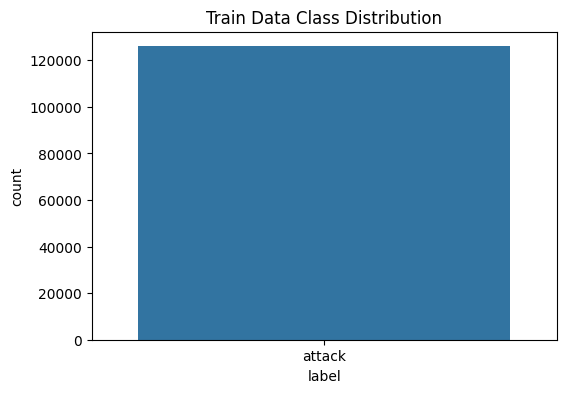

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       1.00      1.00      1.00     22544
      normal       0.00      0.00      0.00         0

    accuracy                           1.00     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       1.00      1.00      1.00     22544



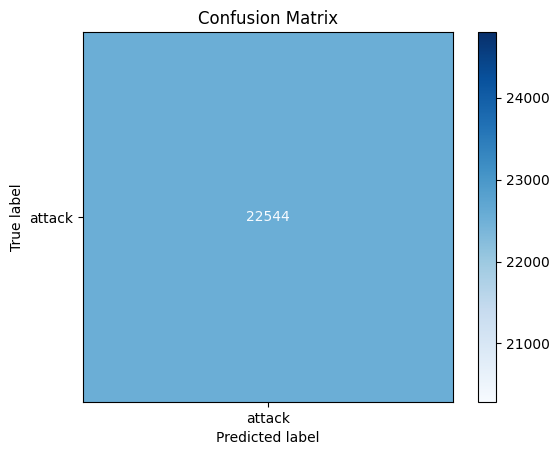

Classes learned by the classifier: ['attack']
Training labels distribution:
 label
attack    125973
Name: count, dtype: int64
Test labels distribution:
 label
attack    22544
Name: count, dtype: int64


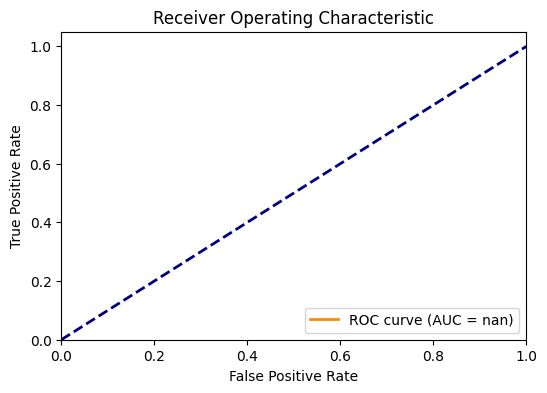

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset (adjust file paths as needed)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)

# Correct column names for NSL-KDD with 43 columns (added 'outcome' and 'label')
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]

train_data.columns = column_names
test_data.columns = column_names

# Binary label encoding: 'normal' or 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# EDA: Visualize class distribution in train data
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()

# Check for missing values
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())

# Feature groups
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])

# Define preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Prepare features and labels
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']

# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train RandomForest model with balanced class weights for imbalanced data
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)

# Predict on test data
y_pred = clf.predict(X_test_preprocessed)

print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
# Print classification report
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred,
    labels=['attack', 'normal'],
    target_names=['attack', 'normal']
))
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve and AUC for normal class
y_test_bin = (y_test == 'normal').astype(int)
print('Classes learned by the classifier:', clf.classes_)
print('Training labels distribution:\n', y_train.value_counts())
print('Test labels distribution:\n', y_test.value_counts())

y_score = clf.predict_proba(X_test_preprocessed)[:, clf.classes_.tolist().index('attack')]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()


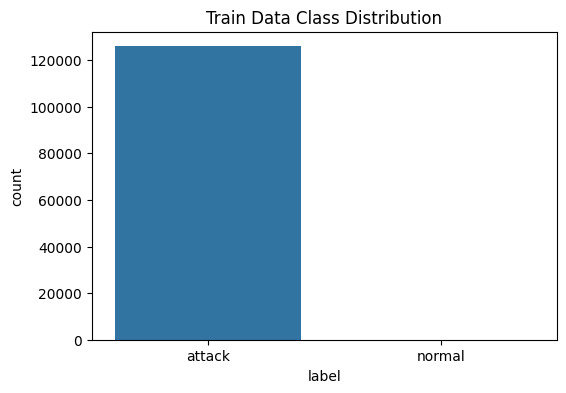

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack' 'normal']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       0.99      1.00      1.00     22421
      normal       0.00      0.00      0.00       123

    accuracy                           0.99     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       0.99      0.99      0.99     22544



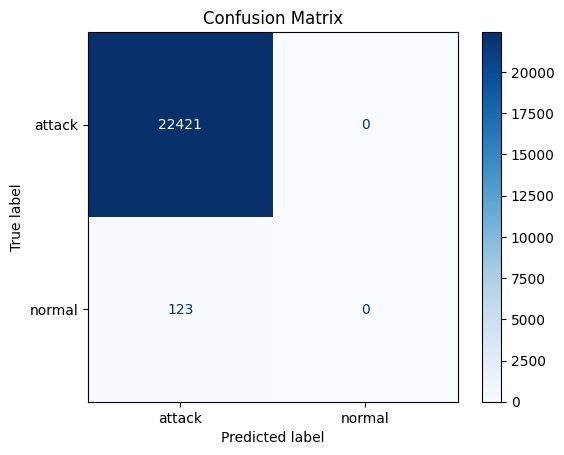

Classes learned by the classifier: ['attack' 'normal']
Training labels distribution:
 label
attack    125907
normal        66
Name: count, dtype: int64
Test labels distribution:
 label
attack    22421
normal      123
Name: count, dtype: int64


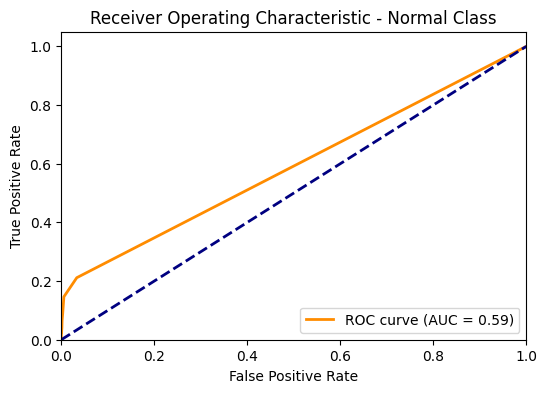

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


# Load dataset (adjust file paths as needed)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)


# Correct column names for NSL-KDD with 43 columns (added 'outcome' and 'label')
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]


train_data.columns = column_names
test_data.columns = column_names


# Correct binary label encoding: 0 -> 'normal', others -> 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')


# EDA: Visualize class distribution in train data
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()


# Check for missing values
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())


# Feature groups
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])


# Define preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# Prepare features and labels
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']


# Preprocess the data
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)


# Train RandomForest model with balanced class weights for imbalanced data
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)


# Predict on test data
y_pred = clf.predict(X_test_preprocessed)


print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
# Print classification report
print('Classification Report:')
print(classification_report(
    y_test,
    y_pred,
    labels=['attack', 'normal'],
    target_names=['attack', 'normal']
))
# Plot confusion matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()


# ROC Curve and AUC for normal class
y_test_bin = (y_test == 'normal').astype(int)
print('Classes learned by the classifier:', clf.classes_)
print('Training labels distribution:\n', y_train.value_counts())
print('Test labels distribution:\n', y_test.value_counts())

normal_class_index = clf.classes_.tolist().index('normal')
y_score = clf.predict_proba(X_test_preprocessed)[:, normal_class_index]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Normal Class')
plt.legend(loc='lower right')
plt.show()


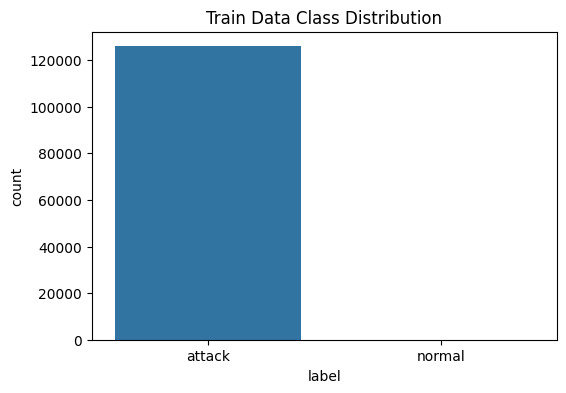

Missing values in train: 0
Missing values in test: 0
Unique classes in y_test: ['attack' 'normal']
Unique classes in y_pred: ['attack']
Classification Report:
              precision    recall  f1-score   support

      attack       0.99      1.00      1.00     22421
      normal       0.00      0.00      0.00       123

    accuracy                           0.99     22544
   macro avg       0.50      0.50      0.50     22544
weighted avg       0.99      0.99      0.99     22544



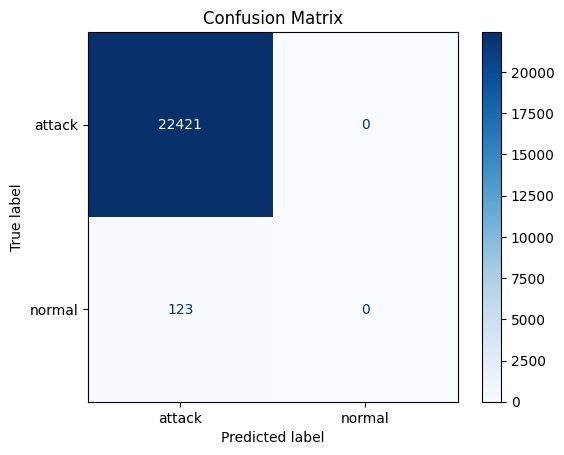

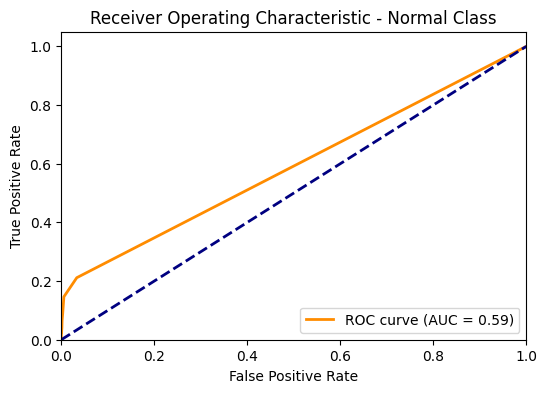

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load dataset (replace file paths to your local machine)
train_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt', header=None)
test_data = pd.read_csv('C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt', header=None)

# NSL-KDD column names (43 columns)
column_names = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent',
    'hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','outcome','label'
]

train_data.columns = column_names
test_data.columns = column_names

# Convert numeric labels to binary: 0 -> 'normal', others -> 'attack'
train_data['label'] = train_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')
test_data['label'] = test_data['label'].apply(lambda x: 'normal' if int(x) == 0 else 'attack')

# EDA - Class Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=train_data, x='label')
plt.title('Train Data Class Distribution')
plt.show()

# Missing values check
print('Missing values in train:', train_data.isnull().sum().sum())
print('Missing values in test:', test_data.isnull().sum().sum())

# Feature separation
categorical_features = ['protocol_type','service','flag']
numeric_features = train_data.columns.difference(categorical_features + ['label','outcome'])

# Preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Prepare data
X_train = train_data.drop(columns=['label','outcome'])
y_train = train_data['label']
X_test = test_data.drop(columns=['label','outcome'])
y_test = test_data['label']

# Preprocess
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Train classifier
clf = RandomForestClassifier(random_state=42, class_weight='balanced', n_estimators=100)
clf.fit(X_train_preprocessed, y_train)

# Predictions
y_pred = clf.predict(X_test_preprocessed)

# Metrics & report
print('Unique classes in y_test:', y_test.unique())
print('Unique classes in y_pred:', np.unique(y_pred))
print('Classification Report:')
print(classification_report(y_test, y_pred, labels=['attack', 'normal'], target_names=['attack', 'normal']))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(clf, X_test_preprocessed, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve & AUC for 'normal' class
y_test_bin = (y_test == 'normal').astype(int)
normal_class_index = clf.classes_.tolist().index('normal')
y_score = clf.predict_proba(X_test_preprocessed)[:, normal_class_index]

fpr, tpr, _ = roc_curve(y_test_bin, y_score)
roc_auc = roc_auc_score(y_test_bin, y_score)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic - Normal Class')
plt.legend(loc='lower right')
plt.show()


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.under_sampling import RandomUnderSampler

train_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTrain+.txt"
test_path = "C:\\Users\\pm5cd\\Documents\\SentinelNet-AI\\SentinelNet\\data\\NSL-KDD\\KDDTest+.txt"

col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
    "count","srv_count","serror_rate","srv_serror_rate","rerror_rate",
    "srv_rerror_rate","same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
    "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","Label"
]

# Load datasets
train_df = pd.read_csv(train_path, names=col_names)
test_df = pd.read_csv(test_path, names=col_names)

print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")



Train data shape: (125973, 42)
Test data shape: (22544, 42)



Training Data Shape: (125973, 42)
Training Data Missing Values per Column:
Series([], dtype: int64)


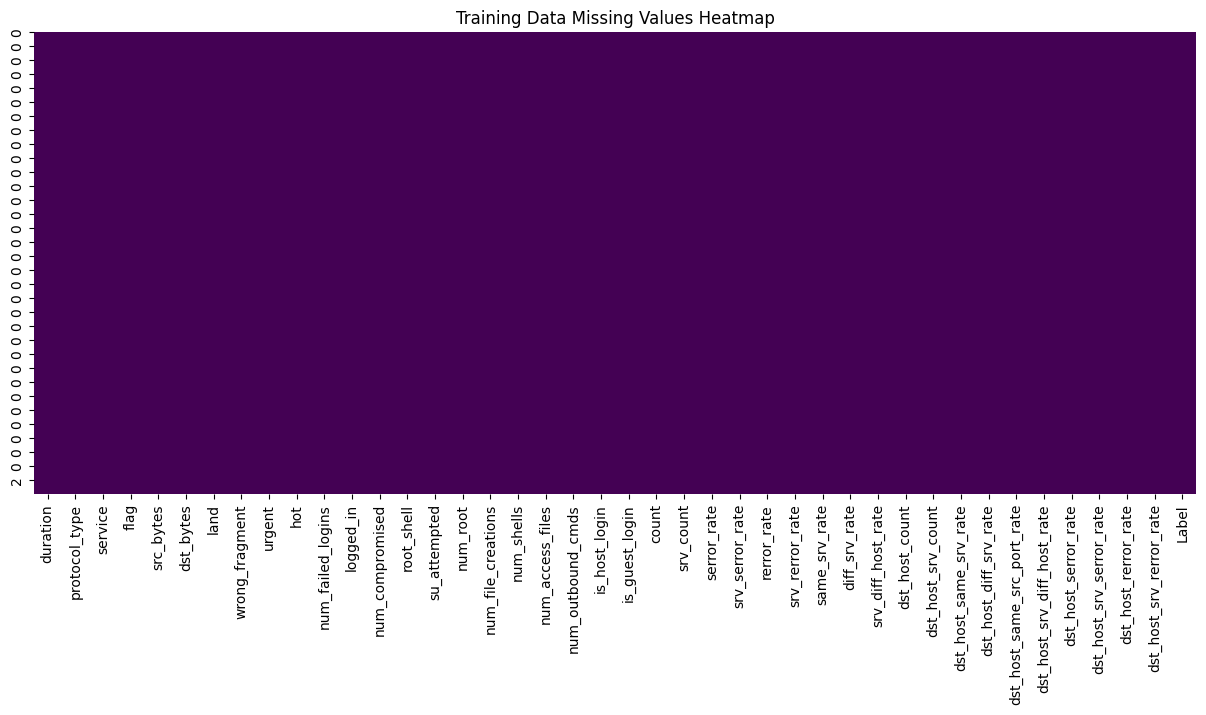

Training Data Duplicates: 1255
Training Data Shape after duplicates drop: (124718, 42)

Testing Data Shape: (22544, 42)
Testing Data Missing Values per Column:
Series([], dtype: int64)


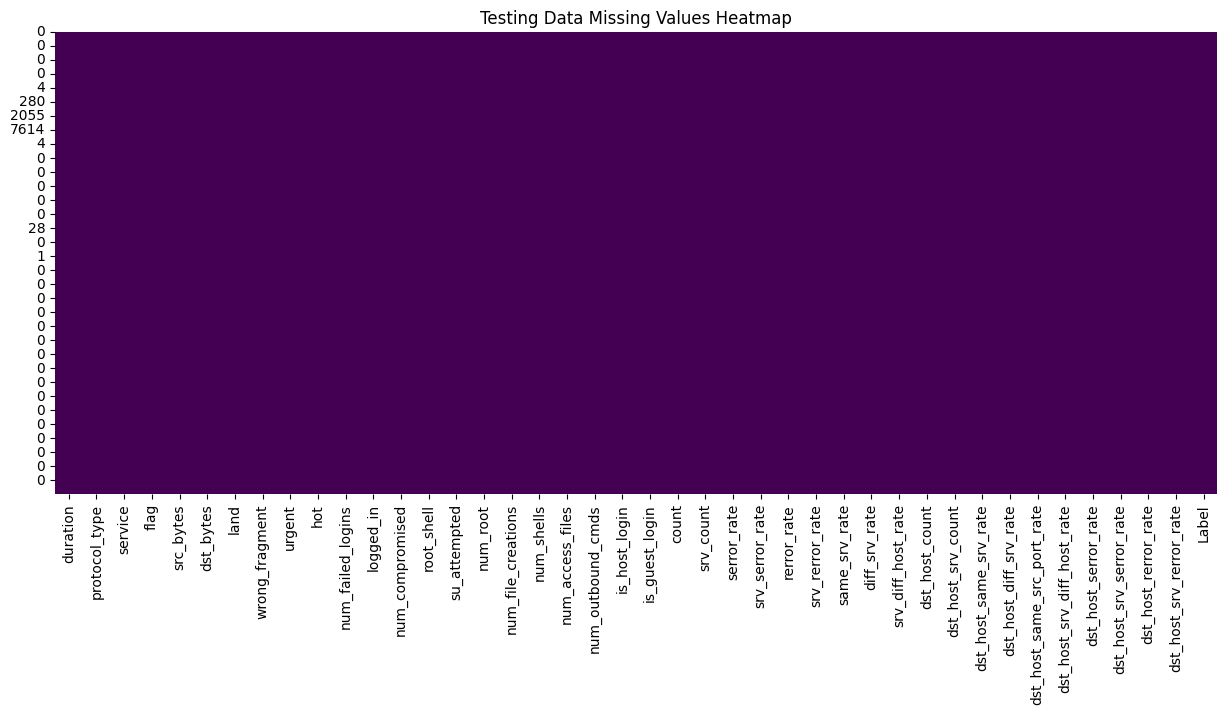

Testing Data Duplicates: 128
Testing Data Shape after duplicates drop: (22416, 42)


In [14]:
# Step 1: Inspect & Visualize Missing Values and Duplicates
def inspect_data(df, name):
    print(f"\n{name} Shape: {df.shape}")
    print(f"{name} Missing Values per Column:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    
    plt.figure(figsize=(15,6))
    sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
    plt.title(f'{name} Missing Values Heatmap')
    plt.show()
    
    dupes = df.duplicated().sum()
    print(f"{name} Duplicates: {dupes}")
    if dupes > 0:
        df.drop_duplicates(inplace=True)
        print(f"{name} Shape after duplicates drop: {df.shape}")

inspect_data(train_df, "Training Data")
inspect_data(test_df, "Testing Data")

Target Distribution:
attack_binary
1    124718
Name: count, dtype: int64



C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\101966704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


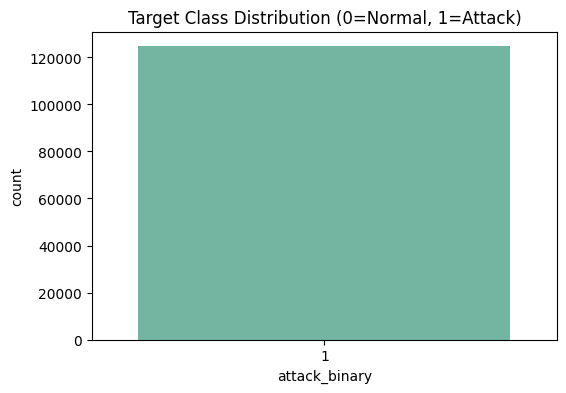

Target Distribution:
attack_binary
1    22416
Name: count, dtype: int64



C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\101966704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='attack_binary', data=df, palette='Set2')


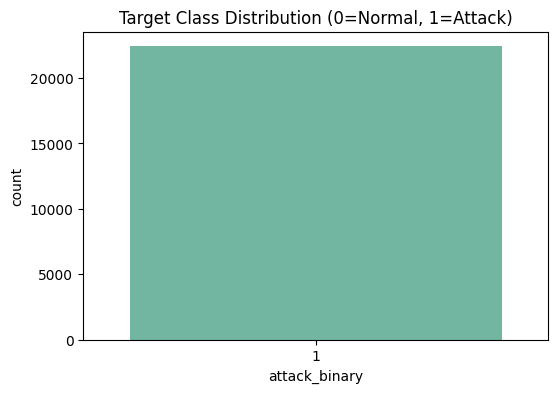

In [15]:
def create_binary_target(df):
    df['attack_binary'] = df['Label'].apply(lambda x: 0 if str(x).strip().lower() == 'normal' else 1)
    counts = df['attack_binary'].value_counts()
    print(f"Target Distribution:\n{counts}\n")
    plt.figure(figsize=(6,4))
    sns.countplot(x='attack_binary', data=df, palette='Set2')
    plt.title("Target Class Distribution (0=Normal, 1=Attack)")
    plt.show()

create_binary_target(train_df)
create_binary_target(test_df)

Training data label distribution BEFORE undersampling:
attack_binary
1    124718
Name: count, dtype: int64


C:\Users\pm5cd\AppData\Local\Temp\ipykernel_30452\747821660.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_df['attack_binary'], palette='Set2')


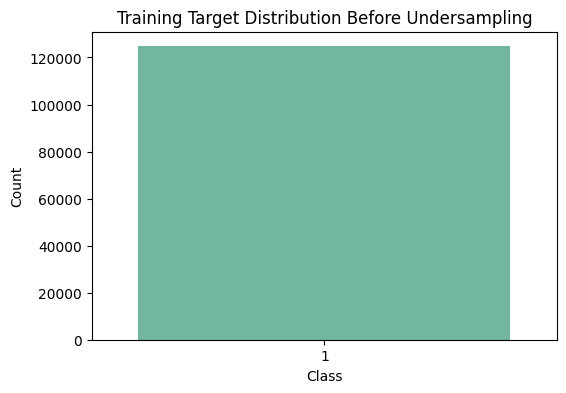

In [20]:
print("Training data label distribution BEFORE undersampling:")
print(train_df['attack_binary'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=train_df['attack_binary'], palette='Set2')
plt.title("Training Target Distribution Before Undersampling")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# Prepare features and labels for undersampling
X_train = train_df.drop(columns=['Label', 'attack_binary'])
y_train = train_df['attack_binary']

if y_train.nunique() < 2:
    print("Warning: Only one class present in training data. Skipping undersampling.")
    X_resampled, y_resampled = X_train, y_train
else:
    print("Balancing training data by undersampling majority class...")
    rus = RandomUnderSampler(random_state=42)
    X_resampled, y_resampled = rus.fit_resample(X_train, y_train)
    print("Training data label distribution AFTER undersampling:")
    print(y_resampled.value_counts())

    plt.figure(figsize=(6,4))
    sns.countplot(x=y_resampled, palette='Set1')
    plt.title("Balanced Training Target Distribution After Undersampling")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

# Creating balanced training DataFrame
train_bal_df = X_resampled.copy()
train_bal_df['attack_binary'] = y_resampled